# 01 · Which topological features respond to which market mechanism?

*A synthetic ground-truth study, run before touching real data.*

Topology doesn't find signals by itself. It describes the shape of recent returns. A signal exists only if some market state changes that shape and the state also predicts what comes next. So before fitting anything to prices, this notebook simulates return series whose mechanism is known and asks four questions.

1. **Response.** Which features move under which mechanism? The mechanisms are fat tails, volatility clustering, regime switches and a genuine cycle.
2. **Scale.** How much of that movement is just volatility? Rips diagrams are homogeneous, so unnormalized features partly measure $\sigma$.
3. **Nulls.** Do the features see structure beyond a within-window shuffle, and beyond a fitted GARCH-t?
4. **Value added.** Does topology see anything that cheap classical statistics don't?

The machinery lives in [`tdasig/`](../tdasig), and [`tests/`](../tests) checks the maths it relies on. Every number below comes from fixed seeds. The whole notebook runs in about six minutes on four cores.

> **Findings at a glance.** These are written from the outputs below.
>
> 1. **Every mechanism moves some topological feature, in the direction the geometry predicts.** Fat tails and regime mixing show up in $H_0$ as two-scale structure: higher `H0_cv`, lower `H0_entropy`, smaller loops. A genuine cycle shows up in `H1_max`. Under the rank transform, i.i.d. fat tails vanish exactly, as they must.
> 2. **Unnormalized features are mostly a volatility estimator.** The decomposition $\log F_{\text{raw}}=k\log\hat\sigma_w+\log F_{\text{vol}}$ is exact. On GARCH windows, $\log\hat\sigma_w$ explains 66% of the variance of the log Gidea–Katz statistic and 99% for total $H_0$ persistence.
> 3. **No topological block beats the classical statistics built for the same mechanism.** Gradient-boosted trees on the classical block match or beat every TDA block (summaries, landscapes, Betti curves, persistence images) for every mechanism, up to cross-validation noise. Adding the TDA blocks changes the AUC by at most +0.03. On GARCH data the TDA features add no forecasting skill over a GARCH baseline (Clark–West p = 0.42 and 0.89).
> 4. **At 5,000 days, regime switching is indistinguishable from a fitted GARCH-t by every feature.** At 40,000 days the normalized $H_1$ summaries are the only features that ever exceed |z| = 3. The $H_1$ landscape norm averages z = 3.4 over four series, while the best classical statistic averages |z| = 2.2. This is the one place topology leads, and it takes about 160 years of data from one series.
> 5. **Even the cycle is a split verdict.** $H_1$ sees what separates a limit cycle from its same-spectrum Gaussian twin, namely the stable amplitude, but only once the cycle carries 70–80% of the variance. The classical envelope statistic `acf_abs` separates them better at every share.
> 6. **The two-scale claim for regime changes holds.** `H0_entropy` and `H0_cv` are the best single detectors of a window that straddles a switch, and they fire within days of a calm → stress switch. Geary's ratio and kurtosis are statistically tied with them, and in a multivariate model TDA adds nothing.
>
> **For the real-data study:**
> - Normalize, and let vol enter as its own regressor.
> - Make GARCH-t surrogates and a GARCH baseline the bar to clear.
> - Pitch topology as an *efficient summary of joint short-horizon geometry*, which is finding 4, and look for it where data can be pooled: across assets or intraday.

In [1]:
import sys
import time
import zlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tdasig").is_dir())
sys.path.insert(0, str(ROOT))

from tdasig import Config
from tdasig import baselines as BL
from tdasig import evaluate as E
from tdasig import features as F
from tdasig import plotting as P
from tdasig import simulate as S
from tdasig import surrogates as SG

P.use_style()
pd.set_option("display.precision", 3)

MASTER_SEED = 2026


def rng_for(name):
    """An independent random stream per experiment, reproducible across sessions."""
    return np.random.default_rng([MASTER_SEED, zlib.crc32(name.encode())])


cfg = Config(w=100, m=4, tau=1, maxdim=1)
print(cfg, f"-> {cfg.n_points} points in R^{cfg.m} per window")

Config(w=100, m=4, tau=1, maxdim=1) -> 97 points in R^4 per window


## 1 · The pipeline

For every window of $w$ daily returns:

1. **Normalize** the window in one of three ways:
   - `raw` leaves it unchanged.
   - `vol` divides by the window's realized vol $\hat\sigma_w$, which removes scale and keeps shape.
   - `rank` maps each return to its rank $/(w+1)$, the empirical copula. This removes the marginal law too and leaves only dependence. An i.i.d. window becomes a uniformly random permutation, whatever its distribution.

   Rips is translation-invariant, so demeaning never matters; only the scale does.
2. **Delay-embed**: $v_t=(r_t,r_{t-\tau},\dots,r_{t-(m-1)\tau})$ gives $n=w-(m-1)\tau$ points in $\mathbb R^m$. Here $w=100$, $m=4$ and $\tau=1$, so $n=97$.
3. **Compute Vietoris–Rips persistence** in degrees 0 and 1 with ripser. Every $H_0$ class is born at $0$, and its death times are exactly the edge lengths of the Euclidean minimum spanning tree.
4. **Summarize.** The heatmaps use scalars. The classifiers use full vectors: landscapes $\lambda_1,\lambda_2,\lambda_3$ and Betti curves on a fixed grid, plus $H_1$ persistence images.

| feature | definition | reads as |
|---|---|---|
| `H0_total` | $\sum_i \ell_i$ over $H_0$, i.e. the MST length | a Rényi entropy of order $3/4$ in disguise (Steele's theorem, heuristically) |
| `H0_max` | longest MST edge | the most isolated point: an extreme day, or a run of them |
| `H0_cv` | sd / mean of the MST edge lengths | two-scale structure: a dense core with a sparse halo |
| `H0_entropy` | $-\sum_i p_i\log p_i$ with $p_i=\ell_i/\sum_j\ell_j$ | how evenly persistence is spread; scale-free |
| `H1_total`, `H1_max`, `H1_entropy` | the same summaries for loops | `H1_max` is the Perea–Harer periodicity score |
| `H1_L1` | $\lVert\lambda\rVert_1$ of the $H_1$ landscape | the crash statistic of Gidea & Katz (2018) |

The **classical baselines** each target one mechanism:

| feature | definition | targets |
|---|---|---|
| `rv` | realized vol | scale |
| `kurt` | excess kurtosis | fat tails |
| `geary` | Geary's ratio, mean $\lvert r-\bar r\rvert/\hat\sigma$: a low-variance robust kurtosis | fat tails |
| `maxabs` | largest standardized move | fat tails |
| `acf1` | lag-1 autocorrelation | linear dependence |
| `acf_abs` | mean lag-1..5 autocorrelation of $\lvert r\rvert$ | volatility clustering |
| `fisher_g` | largest share of the periodogram (Fisher's test for a hidden periodicity) | cycles |
| `vol_ratio` | $\lvert\log(\hat\sigma_{\text{2nd half}}/\hat\sigma_{\text{1st half}})\rvert$ | a vol shift inside the window |

`vol_ratio` is the only statistic in either list that uses the order of the whole window.

### An identity for landscape norms

At each $t$ the landscape values $\{\lambda_k(t)\}_{k\ge1}$ are the tent values $\{\Lambda_{(b_i,d_i)}(t)\}_i$ sorted into decreasing order. So $\sum_k\lambda_k(t)^p=\sum_i\Lambda_{(b_i,d_i)}(t)^p$ for every $t$. Integrating a single tent then gives

$$\lVert\lambda\rVert_p^p \;=\; \sum_k \lVert\lambda_k\rVert_p^p \;=\; \sum_i \int_{\mathbb R}\Lambda_{(b_i,d_i)}(t)^p\,dt \;=\; \sum_i \frac{\ell_i^{\,p+1}}{2^p\,(p+1)},\qquad \ell_i=d_i-b_i .$$

Three consequences follow:
- The full-landscape norm is just a power sum of bar lengths: $\tfrac14\sum_i\ell_i^2$ for $p=1$. It forgets every birth time, and the longest bars dominate it.
- The scaling law $\lVert\lambda^{cX}\rVert_p=c^{1+1/p}\lVert\lambda^X\rVert_p$ is immediate.
- The landscape's positional information survives only if you keep the functions $\lambda_k(t)$ themselves. That is what the vectorized features in §4b do.

(Gidea & Katz use four indices as coordinates rather than delays. The identity holds for any diagram.)

## 2 · Checks on the maths

Three facts carry the rest of the notebook, so check them numerically first. `tests/test_invariants.py` checks them again, along with the surrogate and simulator properties used later:

- **(a)** Rips $H_0$ deaths are exactly the MST edge lengths.
- **(b)** The closed form above agrees with brute-force integration of $\lambda_1,\lambda_2,\dots$.
- **(c)** Under $X\mapsto cX$ each feature scales as $c^{\text{degree}}$. The degree is 2 for $\lVert\lambda\rVert_1$, 1.5 for $\lVert\lambda\rVert_2$, 1 for total persistence and 0 for entropy.

In [2]:
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.spatial.distance import pdist, squareform

rng = rng_for("checks")
X = F.delay_embed(F.normalize(S.garch(cfg.w, 0.08, 0.90, rng)[0], "vol"), cfg.m, cfg.tau)
dg = F.diagrams(X)

# (a) Rips H0 deaths are the MST edge lengths
mst = minimum_spanning_tree(squareform(pdist(X))).toarray()
gap = np.abs(np.sort(dg[0][:, 1]) - np.sort(mst[mst > 0])).max()
print(f"(a) max |H0 death - MST edge| over {len(dg[0])} bars: {gap:.1e}")

# (b) closed-form landscape norm vs brute-force integration of every landscape level
grid = np.linspace(0.0, 1.01 * dg[1][:, 1].max(), 20001)
lam = F.landscape(dg[1], grid, k=len(dg[1]))
for p in (1, 2):
    brute = np.trapezoid((lam ** p).sum(axis=0), grid) ** (1 / p)
    print(f"(b) ||lambda||_{p} of H1: integrated {brute:.6f}, closed form {F.landscape_norm(dg[1], p):.6f}")

# (c) homogeneity: rescale the cloud, refit log F(cX) against log c
cs = np.geomspace(0.25, 4.0, 9)
curves = {
    "||lambda||_1 of H1": (lambda d: F.landscape_norm(d[1], 1), 2.0),
    "||lambda||_2 of H1": (lambda d: F.landscape_norm(d[1], 2), 1.5),
    "total persistence of H0": (lambda d: F.lifetimes(d[0]).sum(), 1.0),
    "persistence entropy of H1": (lambda d: F.persistence_entropy(d[1]), 0.0),
}
fitted = {name: np.polyfit(np.log(cs), np.log([f(F.diagrams(c * X)) for c in cs]), 1)[0]
          for name, (f, _) in curves.items()}
print("(c) slope of log F(cX) on log c:")
display(pd.DataFrame({"fitted slope": fitted,
                      "degree": {k: v[1] for k, v in curves.items()}}).round(4))

(a) max |H0 death - MST edge| over 96 bars: 1.1e-07
(b) ||lambda||_1 of H1: integrated 0.200015, closed form 0.200015
(b) ||lambda||_2 of H1: integrated 0.118326, closed form 0.118326


(c) slope of log F(cX) on log c:


,fitted slope,degree
||lambda||_1 of H1,2.0,2.0
||lambda||_2 of H1,1.5,1.5
total persistence of H0,1.0,1.0
persistence entropy of H1,0.0,0.0


### What a jump and a cycle look like

The thread made two geometric claims. An extreme day $r_s=J$ appears in $m$ delay vectors, near $Je_1,\dots,Je_m$, so it produces $m$ long $H_0$ bars. An oscillation with a stable amplitude embeds as a loop, so it produces one long $H_1$ bar.

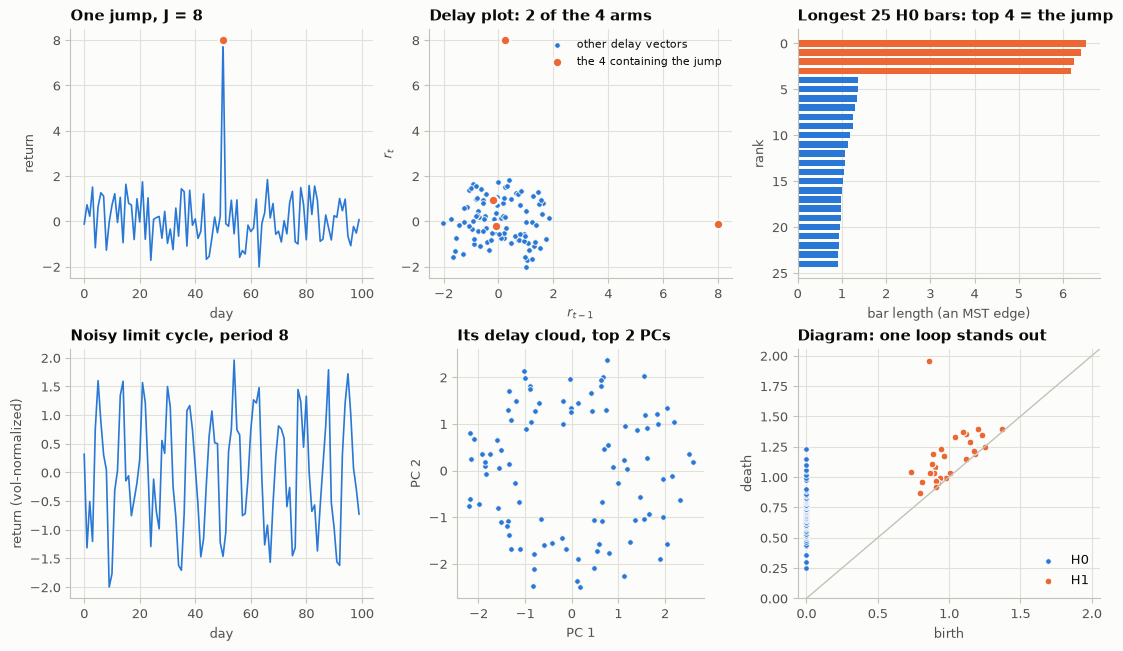

In [3]:
rng = rng_for("jump-and-cycle")
J, day = 8.0, 50
xj = rng.standard_normal(cfg.w)
xj[day] = J
Xj = F.delay_embed(xj, cfg.m, cfg.tau)
has_jump = (Xj == J).any(axis=1)                 # the m delay vectors that contain the jump
bars = np.sort(F.lifetimes(F.diagrams(Xj)[0]))[::-1][:25]

xc = F.normalize(S.limit_cycle(cfg.w, 8, rng, noise=0.3, share=0.8), "vol")
Xc = F.delay_embed(xc, cfg.m, cfg.tau)
dc = F.diagrams(Xc)
Xc0 = Xc - Xc.mean(axis=0)
pcs = Xc0 @ np.linalg.svd(Xc0, full_matrices=False)[2][:2].T

fig, ax = plt.subplots(2, 3, figsize=(11, 6.4))
dot = dict(s=16, lw=0.6, ec=P.SURFACE)

ax[0, 0].plot(xj, color=P.SERIES[0], lw=1.2)
ax[0, 0].scatter([day], [J], color=P.SERIES[1], s=46, lw=1.5, ec=P.SURFACE, zorder=3)
ax[0, 0].set(title="One jump, J = 8", xlabel="day", ylabel="return")

ax[0, 1].scatter(Xj[~has_jump, 1], Xj[~has_jump, 0], color=P.SERIES[0], label="other delay vectors", **dot)
ax[0, 1].scatter(Xj[has_jump, 1], Xj[has_jump, 0], color=P.SERIES[1], s=46, lw=1.5, ec=P.SURFACE,
                 label=f"the {has_jump.sum()} containing the jump")
ax[0, 1].set(title="Delay plot: 2 of the 4 arms", xlabel="$r_{t-1}$", ylabel="$r_t$")
ax[0, 1].legend(loc="upper right", fontsize=8)

ax[0, 2].barh(np.arange(len(bars)), bars, height=0.7,
              color=[P.SERIES[1] if i < cfg.m else P.SERIES[0] for i in range(len(bars))])
ax[0, 2].invert_yaxis()
ax[0, 2].set(title=f"Longest 25 H0 bars: top {cfg.m} = the jump",
             xlabel="bar length (an MST edge)", ylabel="rank")

ax[1, 0].plot(xc, color=P.SERIES[0], lw=1.2)
ax[1, 0].set(title="Noisy limit cycle, period 8", xlabel="day", ylabel="return (vol-normalized)")

ax[1, 1].scatter(pcs[:, 0], pcs[:, 1], color=P.SERIES[0], **dot)
ax[1, 1].set(title="Its delay cloud, top 2 PCs", xlabel="PC 1", ylabel="PC 2", aspect="equal")

top = 1.05 * max(dc[0][:, 1].max(), dc[1][:, 1].max())
ax[1, 2].plot([0, top], [0, top], color=P.BASELINE, lw=1)
ax[1, 2].scatter(dc[0][:, 0], dc[0][:, 1], color=P.SERIES[0], label="H0", **dot)
ax[1, 2].scatter(dc[1][:, 0], dc[1][:, 1], color=P.SERIES[1], s=24, lw=0.8, ec=P.SURFACE, label="H1")
ax[1, 2].set(title="Diagram: one loop stands out", xlabel="birth", ylabel="death",
             xlim=(-0.03 * top, top), ylim=(0, top))
ax[1, 2].legend(loc="lower right")
plt.show()

Both claims hold.

- **The jump.** Each of the four jump vectors sits about $\lvert J\rvert$ from the core, less the core's own reach, and about $\sqrt2\lvert J\rvert$ from the others. So each merges into the core separately, giving $m=4$ long bars. The delay plot shows only the arms along $r_t$ and $r_{t-1}$. The other two point along $r_{t-2}$ and $r_{t-3}$, so they project into the core. This is why `H0_max` and `H0_cv` behave like tail statistics.
- **The cycle.** The period-8 oscillation embeds as a ring with one clearly persistent $H_1$ class. With $m=4$ and $\tau=1$, a pure sinusoid of period $P=2m\tau=8$ embeds as an *exact* circle, because $\sum_{k<m}e^{-2ik\phi}=0$ at $\phi=2\pi\tau/P$. This generator is therefore a deliberately favourable case for $H_1$.

## 3 · Ground-truth generators

| generator | mechanism | specification | isolates |
|---|---|---|---|
| Gaussian | none (the null) | i.i.d. $N(0,1)$ | the featureless ellipsoidal blob |
| Student-t | fat tails | i.i.d. $t_4$, scaled to unit variance | tails with no temporal structure |
| GARCH | volatility clustering | GARCH(1,1), $\alpha=0.08$, $\beta=0.90$, Gaussian innovations | clustering, plus the fat unconditional tails it implies |
| Regime GARCH | regime switches | the same GARCH $\times\,\sigma_{s_t}$, with $\sigma\in\{1,\,2.5\}$ and $s_t$ Markov with mean stays of 400 (calm) and 150 (stress) days | sharp scale shifts at known dates |
| Limit cycle | a genuine loop | Stuart–Landau (Hopf normal form), period 8, phase noise 0.3, 80% of variance, plus white noise | a stable amplitude with a diffusing phase |

Each series is standardized as a whole, by one affine map, so every generator has unit unconditional variance and they differ only in their within-series structure.

The regime model multiplies a unit GARCH by the regime's scale. That makes every switch date a sharp change point in volatility, which the mixture formulations of Markov-switching GARCH don't guarantee.

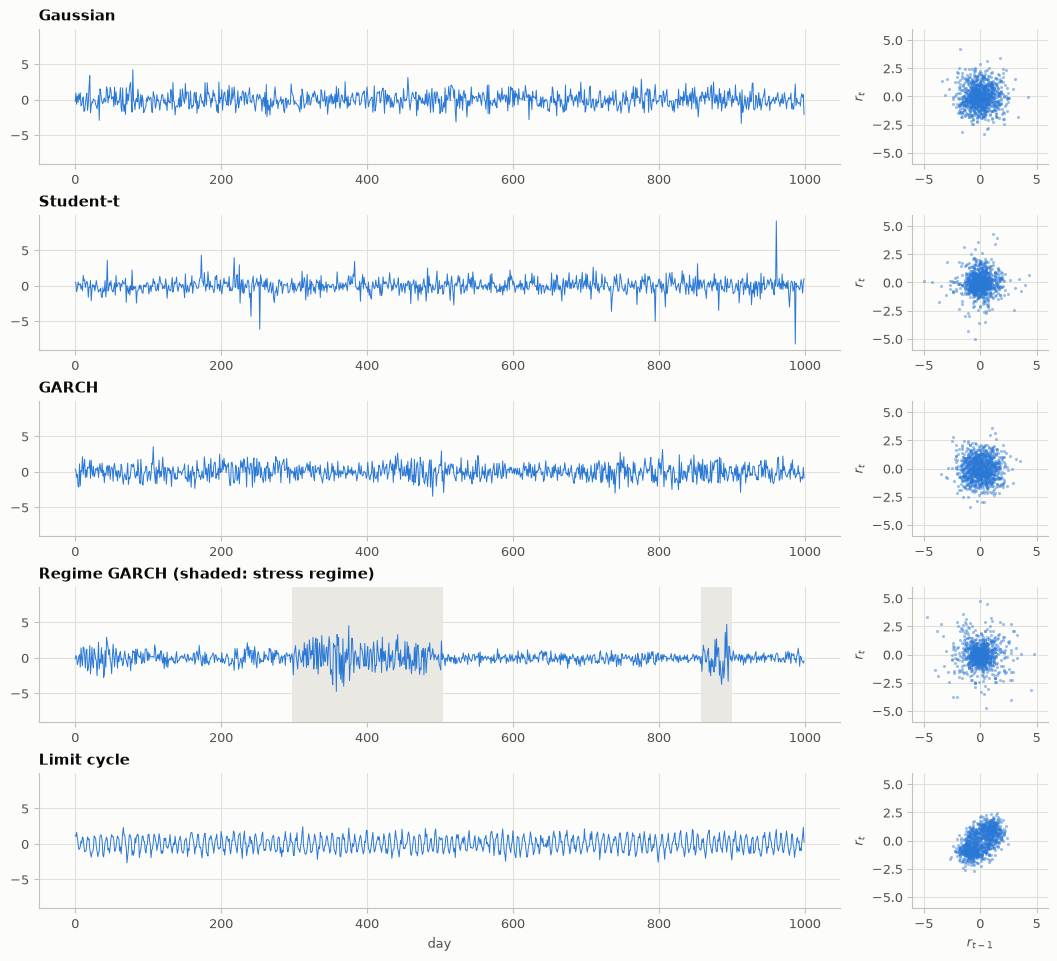

In [4]:
GEN = {
    "Gaussian": {},
    "Student-t": dict(nu=4),
    "GARCH": dict(alpha=0.08, beta=0.90),
    "Regime GARCH": dict(alpha=0.08, beta=0.90, scales=(1.0, 2.5), durations=(400, 150)),
    "Limit cycle": dict(period=8, noise=0.3, share=0.8),
}


def simulate(name, n, rng):
    """One series of length n from generator `name`, standardized to unit variance."""
    base = name.split(" (")[0]               # "Gaussian (fresh draw)" -> "Gaussian"
    kw = GEN[base]
    if base == "Gaussian":
        x = S.gaussian(n, rng)
    elif base == "Student-t":
        x = S.student_t(n, kw["nu"], rng)
    elif base == "GARCH":
        x, _ = S.garch(n, rng=rng, **kw)
    elif base == "Regime GARCH":
        x, _ = S.regime_garch(n, rng=rng, **kw)
    else:
        x = S.limit_cycle(n, rng=rng, **kw)
    return S.standardize(x)


rng = rng_for("gallery")
fig, axes = plt.subplots(5, 2, figsize=(11, 9.5), gridspec_kw={"width_ratios": [3.3, 1]}, sharey="col")
for name, (a_path, a_delay) in zip(GEN, axes):
    if name == "Regime GARCH":
        r, st = S.regime_garch(1000, rng=rng, **GEN[name])
        x = S.standardize(r)
        edges = np.flatnonzero(np.diff(np.r_[0, st, 0]))
        for a, b in zip(edges[::2], edges[1::2]):
            a_path.axvspan(a, b, color=P.SHADE, lw=0)
        title = "Regime GARCH (shaded: stress regime)"
    else:
        x = simulate(name, 1000, rng)
        title = name
    a_path.plot(x, color=P.SERIES[0], lw=0.7)
    a_path.set_title(title)
    a_delay.scatter(x[:-1], x[1:], s=5, color=P.SERIES[0], alpha=0.45, lw=0)
    a_delay.set(xlim=(-6, 6), ylim=(-6, 6), aspect="equal")
    a_delay.set_ylabel("$r_t$")
axes[-1, 0].set_xlabel("day")
axes[-1, 1].set_xlabel("$r_{t-1}$")
plt.show()

## 4 · Which features respond to which mechanism?

For each generator, take 400 non-overlapping windows, and compare every feature against a sample of 1,600 i.i.d. Gaussian windows using

$$D \;=\; 2\cdot\mathrm{AUC}-1 \;=\; P(\text{feature}_{\text{gen}}>\text{feature}_{\text{null}})-P(\text{feature}_{\text{gen}}<\text{feature}_{\text{null}}) .$$

$D$ is rank-based, so it is scale-free and robust to heavy tails. It reads $+1$ when every generator window exceeds every null window and $0$ when the two are indistinguishable. The standard error is about 0.03, so $\lvert D\rvert\lesssim0.1$ is noise. The *Gaussian (fresh draw)* column shows that floor directly.

**Predictions, written before looking:**

- **Fat tails.** $H_0$ should behave like kurtosis: the extreme days are isolated points. At fixed variance the core is denser, so $H_1$ loops should shrink. *Nothing* should survive `rank`.
- **Clustering and regimes.** Expect two-scale structure ($H_0$ CV up, $H_0$ entropy down), with `acf_abs` firing too.
- **Cycle.** `H1_max` should go up, and so should the spectral statistics `acf1` and `fisher_g`.
- **`raw`.** Features should move with each window's vol, whatever the mechanism.

In [5]:
N_WIN, N_NULL = 400, 1600
GENS = ["Gaussian (fresh draw)", "Student-t", "GARCH", "Regime GARCH", "Limit cycle"]
ROWS = list(F.CLASSICAL) + list(F.TDA_SCALARS)

series = {g: simulate(g, N_WIN * cfg.w, rng_for("response/" + g)) for g in GENS}
series["null"] = simulate("Gaussian", N_NULL * cfg.w, rng_for("response/null"))

t0 = time.time()
feats, dgms = {}, {}
for norm in F.NORMALIZATIONS:
    for g, x in series.items():
        feats[norm, g], dgms[norm, g] = F.compute_features(F.make_windows(x, cfg.w)[0], norm, cfg,
                                                           keep_diagrams=True)
print(f"{sum(len(v) for v in feats.values()):,} windows -> Rips persistence + features "
      f"in {time.time() - t0:.0f}s")

resp = {norm: E.response_matrix({g: feats[norm, g] for g in GENS}, feats[norm, "null"], ROWS)
        for norm in F.NORMALIZATIONS}

10,800 windows -> Rips persistence + features in 16s


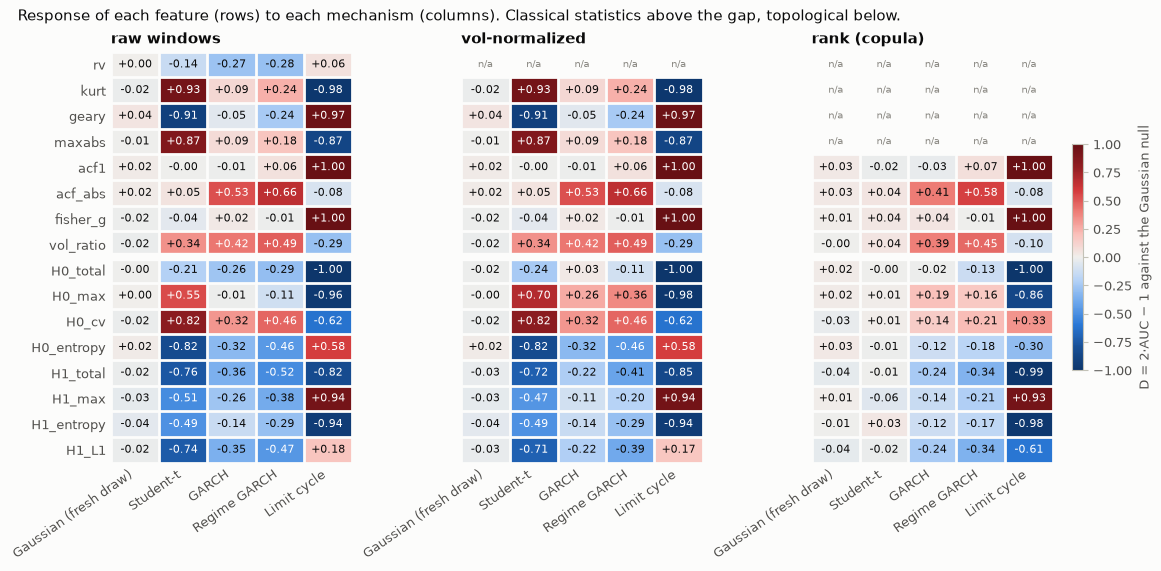

In [6]:
TITLES = {"raw": "raw windows", "vol": "vol-normalized", "rank": "rank (copula)"}
fig, axes = plt.subplots(1, 3, figsize=(11.5, 5.6), sharey=True)
for ax, norm in zip(axes, F.NORMALIZATIONS):
    im = P.heatmap(ax, resp[norm], P.DIVERGING, -1, 1)
    ax.axhline(len(F.CLASSICAL) - 0.5, color=P.SURFACE, lw=6)
    ax.set_title(TITLES[norm])
fig.colorbar(im, ax=axes, shrink=0.55, pad=0.02, label="D = 2·AUC − 1 against the Gaussian null")
fig.suptitle("Response of each feature (rows) to each mechanism (columns). "
             "Classical statistics above the gap, topological below.", x=0.01, ha="left", fontsize=10.5)
plt.show()

**Reading the heatmap.**

- **Calibration.** The fresh Gaussian column stays within ±0.04. Under `rank` the Student-t column is null to the same precision (|D| ≤ 0.06), as it must be: an i.i.d. window's ranks are a uniformly random permutation, whatever the marginal. The rank transform really does strip out everything but dependence.
- **Fat tails** (vol-normalized) light up the $H_0$ features almost as strongly as the moment statistics: `H0_cv` +0.82 and `H0_entropy` −0.82, against `kurt` +0.93 and `geary` −0.91. The prediction about loops holds too. At fixed variance a heavy-tailed window has a denser core, so $H_1$ shrinks (`H1_total` −0.72, `H1_L1` −0.71).
- **Clustering and regimes** produce the predicted two-scale signature (`H0_cv` +0.32 and +0.46), but more weakly than the dedicated clustering statistic (`acf_abs` +0.53 and +0.66).
  - One detail is genuinely geometric. Under clustering `H0_max` responds (+0.26 and +0.36) while the single most extreme day barely moves (`maxabs` +0.09 and +0.18). A delay vector sees a *run* of large moves as one outlying point, which a one-dimensional statistic cannot.
  - Under `rank`, clustering still registers through dependence alone (`H1_total` −0.24 and −0.34), again more weakly than `acf_abs`.
- **The cycle** saturates almost everything. `H1_max` reads +0.94, but `acf1` and `fisher_g` read +1.00, and the cycle's platykurtic marginal gives `kurt` −0.98. The Gidea–Katz norm `H1_L1` is the weakest loop detector in the table (+0.17). The identity from §1 explains why: $\sum_i\ell_i^2$ adds the one long bar to dozens of short noise bars, and here the gain is largely offset by the loss of noise loops (`H1_total` −0.85).
- **Raw windows mix scale with shape, and the two can cancel.** `rv` sits below the null for every fat-tailed or clustered generator (−0.14 to −0.28), because at unit variance most windows are quieter than average. That drags the raw features down, so raw `H0_max` reads −0.01 on GARCH while its vol-normalized version reads +0.26.

### 4b · Does topology add anything the classical statistics don't already see?

A univariate response isn't the question that matters. What matters is whether a TDA block carries information that the classical block doesn't. So train gradient-boosted trees to separate each mechanism's windows from null windows, once per feature block, and compare cross-validated AUCs.

The vectorizations use grids fixed per normalization, pooled over all generators:
- landscapes $\lambda_{1..3}$ for $H_0$ and $H_1$ on 50 filtration values;
- Betti curves $\beta_0,\beta_1$ on the same grid;
- $12\times12$ $H_1$ persistence images with a linear weight vanishing on the diagonal.

The cycle is omitted from this table because every block scores ≈ 1.00 there.

36 cross-validated boosted-tree fits in 70s


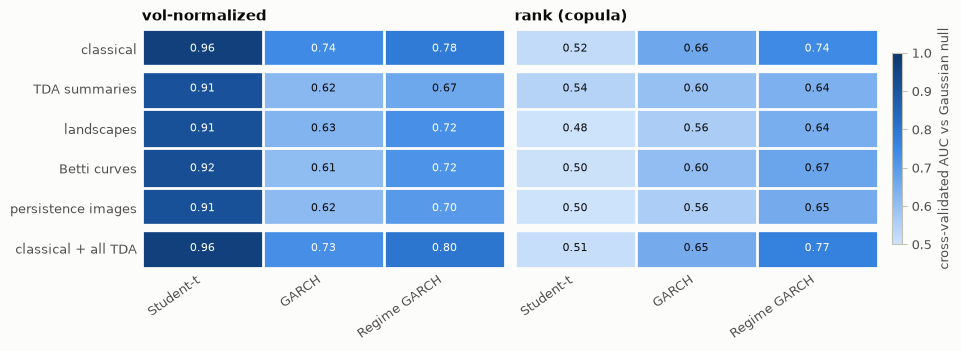

In [7]:
t0 = time.time()
grids = {norm: F.make_grids(sum((dgms[norm, g] for g in [*GENS, "null"]), []))
         for norm in F.NORMALIZATIONS}
vecs = {(norm, g): F.vectorize_all(dgms[norm, g], grids[norm])
        for norm in F.NORMALIZATIONS for g in [*GENS, "null"]}


def feature_blocks(norm, g, n_null=N_WIN):
    """Feature blocks for windows of `g` (label 1) against the first n_null null windows (label 0)."""
    a, b = feats[norm, g], feats[norm, "null"].iloc[:n_null]
    va, vb = vecs[norm, g], {k: v[:n_null] for k, v in vecs[norm, "null"].items()}
    blocks = {
        "classical": np.vstack([a[list(F.CLASSICAL)], b[list(F.CLASSICAL)]]),
        "TDA summaries": np.vstack([a[list(F.TDA_SCALARS)], b[list(F.TDA_SCALARS)]]),
        "landscapes": np.vstack([va["landscape"], vb["landscape"]]),
        "Betti curves": np.vstack([va["betti"], vb["betti"]]),
        "persistence images": np.vstack([va["image"], vb["image"]]),
    }
    blocks["classical + all TDA"] = np.hstack(list(blocks.values()))
    return blocks, np.r_[np.ones(len(a)), np.zeros(len(b))]


MECH = ["Student-t", "GARCH", "Regime GARCH"]
auc_tab = {}
for norm in ("vol", "rank"):
    for g in MECH:
        blocks, y = feature_blocks(norm, g)
        auc_tab[norm, g] = {k: E.cv_auc(X, y) for k, X in blocks.items()}
auc_tab = pd.DataFrame(auc_tab)
print(f"{auc_tab.size} cross-validated boosted-tree fits in {time.time() - t0:.0f}s")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4), sharey=True)
for ax, norm in zip(axes, ("vol", "rank")):
    im = P.heatmap(ax, auc_tab[norm], P.SEQUENTIAL, 0.5, 1.0, fmt="{:.2f}")
    ax.axhline(0.5, color=P.SURFACE, lw=6)
    ax.axhline(4.5, color=P.SURFACE, lw=6)
    ax.set_title(TITLES[norm])
fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02, label="cross-validated AUC vs Gaussian null")
plt.show()

The comparison uses boosted trees rather than a linear model on purpose. On `raw` windows a linear model makes topology look better than it is: a Betti curve on a fixed grid is a *nonlinear basis in scale*, while `rv` enters a logistic regression only linearly. Regime GARCH windows have vol that is either lower *or* higher than the null's, and no linear function of `rv` can express that.

In [8]:
blocks, y = feature_blocks("raw", "Regime GARCH")
display(pd.DataFrame({model: {k: E.cv_auc(blocks[k], y, model=model) for k in ("classical", "Betti curves")}
                      for model in ("logistic", "boosting")}).round(3)
        .rename_axis("raw windows, Regime GARCH vs null"))

,logistic,boosting
"raw windows, Regime GARCH vs null",,
classical,0.842,0.983
Betti curves,0.972,0.977


**Reading the classifier tables.**

- **Vol-normalized.** The classical block beats every TDA block for every mechanism: 0.96 against 0.91–0.92 for fat tails, 0.74 against 0.61–0.63 for GARCH, and 0.78 against 0.67–0.72 for regimes. Adding all the TDA blocks to the classical one changes the AUC by −0.01 to +0.02.
- **Rank.** The Student-t column sits at chance for every block, as it should. Elsewhere the classical block again leads. The largest TDA increment anywhere is +0.03, on Regime GARCH (0.74 → 0.77), which is within cross-validation noise for 800 windows.
- **Vectorizations.** Landscapes, Betti curves and persistence images land within about ±0.05 of the eight scalar summaries. The positional detail they keep buys little here.
- **The linear-model trap.** With a logistic regression on `raw` windows, Betti curves appear to beat the classical block by 0.13 (0.97 against 0.84). With boosted trees the gap disappears (0.98 against 0.98). When comparing feature sets, use a learner flexible enough that you compare information, not bases.

## 5 · The volatility trap

Rips is homogeneous, $\mathrm{Dgm}(cX)=c\,\mathrm{Dgm}(X)$, and the raw window is $\hat\sigma_w$ times the vol-normalized one plus a constant. So for a feature of homogeneity degree $k$ the decomposition is **exact**:

$$\log F_{\text{raw}} \;=\; k\,\log\hat\sigma_w \;+\; \log F_{\text{vol}} .$$

The OLS slope of $\log F_{\text{raw}}$ on $\log\hat\sigma_w$ is therefore $k$ plus the slope of the normalized feature. The $R^2$ says how much of a raw feature is scale.

Test it on a long GARCH path: 80,000 days, windows every 10 days.

In [9]:
rng = rng_for("vol-trap")
T_TRAP, HORIZON, STEP = 80_000, 22, 10
x = simulate("GARCH", T_TRAP, rng)
W, ends = F.make_windows(x, cfg.w, step=STEP)
keep = ends + HORIZON < len(x)
W, ends = W[keep], ends[keep]

t0 = time.time()
f_raw, _ = F.compute_features(W, "raw", cfg)
f_vol, _ = F.compute_features(W, "vol", cfg)
print(f"{2 * len(W):,} windows in {time.time() - t0:.0f}s")

log_sig = np.log(W.std(axis=1))
DEGREE = {"H0_total": 1, "H0_max": 1, "H1_total": 1, "H1_max": 1, "H1_L1": 2}
decomp = {}
for f, k in DEGREE.items():
    y_raw, y_vol = np.log(f_raw[f]), np.log(f_vol[f])
    b_raw, b_vol = np.polyfit(log_sig, y_raw, 1)[0], np.polyfit(log_sig, y_vol, 1)[0]
    decomp[f] = {"degree k": k, "slope, raw": b_raw, "k + slope, vol-normalized": k + b_vol,
                 "R² on log σ, raw": np.corrcoef(log_sig, y_raw)[0, 1] ** 2,
                 "R² on log σ, vol-normalized": np.corrcoef(log_sig, y_vol)[0, 1] ** 2}
display(pd.DataFrame(decomp).T.round(3))

15,976 windows in 21s


,degree k,"slope, raw","k + slope, vol-normalized","R² on log σ, raw","R² on log σ, vol-normalized"
H0_total,1.0,1.003,1.003,0.986,0.001
H0_max,1.0,1.076,1.076,0.697,0.011
H1_total,1.0,0.903,0.903,0.527,0.013
H1_max,1.0,0.952,0.952,0.589,0.004
H1_L1,2.0,1.855,1.855,0.656,0.012


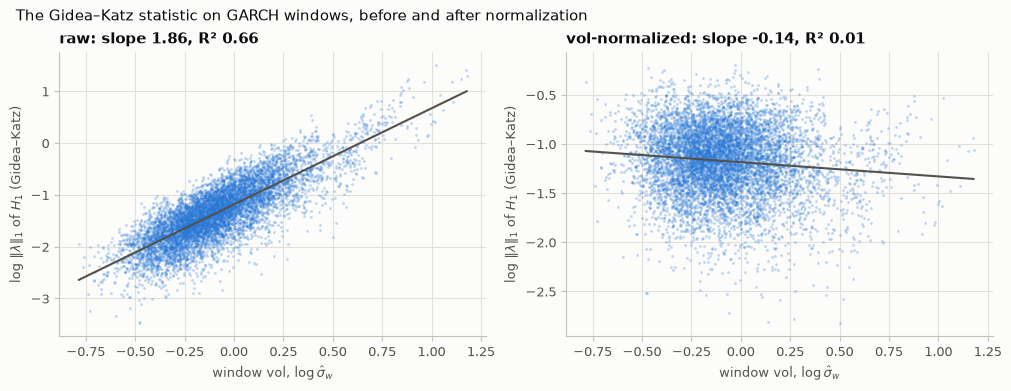

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharex=True)
for ax, (label, frame) in zip(axes, [("raw", f_raw), ("vol-normalized", f_vol)]):
    yv = np.log(frame["H1_L1"])
    b, a = np.polyfit(log_sig, yv, 1)
    ax.scatter(log_sig, yv, s=4, color=P.SERIES[0], alpha=0.3, lw=0)
    xs = np.array([log_sig.min(), log_sig.max()])
    ax.plot(xs, a + b * xs, color=P.INK_2, lw=1.5)
    r2 = np.corrcoef(log_sig, yv)[0, 1] ** 2
    ax.set(title=f"{label}: slope {b:.2f}, R² {r2:.2f}", xlabel=r"window vol, $\log\hat\sigma_w$",
           ylabel=r"$\log\,\Vert\lambda\Vert_1$ of $H_1$ (Gidea–Katz)")
fig.suptitle("The Gidea–Katz statistic on GARCH windows, before and after normalization",
             x=0.01, ha="left", fontsize=10.5)
plt.show()

### A negative control for the forecasting pipeline

On GARCH data we *know* topology has nothing to add, because the conditional variance is a function of the GARCH filter alone. So this is a clean test of the evaluation pipeline, run before it is ever pointed at real data.

- **Target:** log realized variance over the next 22 days.
- **Estimation:** OLS on the first half of the windows; evaluation on the second half.
- **Loss:** QLIKE on the bias-corrected variance forecasts.
- **Test:** Clark–West, because each "+ TDA" model nests its baseline. It uses Newey–West errors because the 22-day targets overlap.
- **Baselines:** HAR-style (log realized variance over 5, 22 and 100 days) and the variance forecast of a GARCH(1,1)-t fitted on the training half.

In [11]:
n = len(ends)
split = n // 2
test = slice(split, n)
target = BL.future_rv(x, ends, HORIZON)
y = np.log(target)

har = BL.har_design(x, ends, lags=(5, 22, 100))
gp = SG.fit_garch_t(x[: ends[split] + 1])                         # fitted on the training span only
h = BL.garch_filter(x, gp["omega"], gp["alpha"], gp["beta"])
garch_fc = np.log(BL.garch_mean_forecast(h[ends + 1], gp["omega"], gp["alpha"], gp["beta"], HORIZON))[:, None]
tda_raw = np.log(f_raw[["H1_L1", "H0_total"]].to_numpy())
tda_vol = f_vol[list(F.TDA_SCALARS)].to_numpy()

MODELS = {  # name: (regressors, the nested baseline it is tested against)
    "raw TDA alone": (tda_raw, None),
    "HAR": (har, None),
    "HAR + raw TDA": (np.hstack([har, tda_raw]), "HAR"),
    "HAR + normalized TDA": (np.hstack([har, tda_vol]), "HAR"),
    "GARCH": (garch_fc, None),
    "GARCH + raw TDA": (np.hstack([garch_fc, tda_raw]), "GARCH"),
    "GARCH + normalized TDA": (np.hstack([garch_fc, tda_vol]), "GARCH"),
}


def ols_forecast(X):
    X1 = np.column_stack([np.ones(n), X])
    beta = np.linalg.lstsq(X1[:split], y[:split], rcond=None)[0]
    return X1 @ beta


pred = {k: ols_forecast(X) for k, (X, _) in MODELS.items()}
mse_const = np.mean((y[test] - y[:split].mean()) ** 2)
fc_tab = {}
for k, (_, base) in MODELS.items():
    bias = np.mean(target[:split] / np.exp(pred[k][:split]))      # in-sample correction for exp(log forecast)
    fc_tab[k] = {"out-of-sample R² (log RV)": 1 - np.mean((y[test] - pred[k][test]) ** 2) / mse_const,
                 "QLIKE": E.qlike(target[test], bias * np.exp(pred[k][test])).mean()}
    if base:
        t, p = E.clark_west(y[test], pred[base][test], pred[k][test], lag=int(np.ceil(HORIZON / STEP)))
        fc_tab[k].update({"Clark–West t": t, "p (H0: TDA adds nothing)": p})
print(f"GARCH-t fitted on the training half: " + ", ".join(f"{k}={v:.3f}" for k, v in gp.items()))
display(pd.DataFrame(fc_tab).T.round(4))

GARCH-t fitted on the training half: omega=0.018, alpha=0.082, beta=0.900, nu=134.783


,out-of-sample R² (log RV),QLIKE,Clark–West t,p (H0: TDA adds nothing)
raw TDA alone,0.159,0.182,NaN,NaN
HAR,0.370,0.136,NaN,NaN
HAR + raw TDA,0.368,0.137,1.274,0.101
HAR + normalized TDA,0.365,0.137,0.685,0.247
GARCH,0.399,0.130,NaN,NaN
GARCH + raw TDA,0.397,0.130,0.196,0.422
GARCH + normalized TDA,0.393,0.131,-1.242,0.893


**Reading §5.**

- **The decomposition is exact.** The raw slope equals $k$ plus the normalized slope, to three decimals.
  - Total $H_0$ persistence is 99% scale ($R^2$ = 0.986), and even the Gidea–Katz statistic is 66% scale.
  - Its raw slope is 1.86 rather than 2 only because high-vol GARCH windows are also slightly less loopy once normalized (normalized slope −0.14).
  - After normalization, scale explains at most 1.3% of any feature.
- **The raw statistic "predicts" future volatility** (out-of-sample $R^2$ = 0.16 on its own), purely as a noisy vol estimator. It adds nothing to either baseline.
- **Against the fitted GARCH, which is the right bar on this data, neither TDA version helps** (Clark–West p = 0.42 and 0.89), and QLIKE does not improve (0.130 → 0.130 and 0.131).
- **Against HAR the p-values run lower** (0.10 and 0.25). HAR is only an approximation to the GARCH filter, so any feature correlated with the part it misses can look useful. On real data, beating HAR is not beating GARCH: keep both baselines.

## 6 · Is there structure beyond a null model?

This is the surrogate-data test (Theiler et al. 1992), set up the way the real data will be:

1. Take one "observed" series of 5,000 days, about 20 years of daily data.
2. Compute the mean of each feature over its 50 windows.
3. Compare that mean with the same statistic on $B=49$ surrogates from each null. The heatmap shows the z-score against the surrogate distribution.

The two nulls are:
- **shuffle**, which permutes the days inside each window. It keeps each window's marginal and vol and kills all temporal order.
- **GARCH-t**, which fits a GARCH(1,1) with Student-t innovations to the observed series and simulates from it. It keeps vol clustering and fat tails and kills anything else.

**The pattern it *should* show**, if the features are working:

| generator | vs shuffle | vs GARCH-t |
|---|---|---|
| Gaussian | consistent | consistent |
| Student-t | consistent: i.i.d. has no order to shuffle | consistent: the fit gives α≈0 and ν≈4 |
| GARCH | **rejected**: clustering is temporal | consistent: it *is* the null |
| Regime GARCH | **rejected** | open question |
| Limit cycle | **rejected** | **rejected** |

Some cells are *n/a* because the statistic can't differ from its null by construction:
- `rv` is constant after `vol` normalization, and `kurt`, `geary` and `maxabs` are constant after `rank`.
- A within-window shuffle leaves every function of the window's marginal unchanged. That covers `kurt`, `geary` and `maxabs`.

In [12]:
B, N_OBS = 49, 50
SUR_GENS = ["Gaussian", "Student-t", "GARCH", "Regime GARCH", "Limit cycle"]
NULLS = ["shuffle", "GARCH-t"]


def surrogate_z(W, surrogate_windows, norm):
    """z-score of each feature's window-mean in W against its window-means over the surrogates."""
    obs = F.compute_features(W, norm, cfg)[0][ROWS].mean()
    sur = F.compute_features(surrogate_windows, norm, cfg)[0][ROWS]
    per_draw = sur.groupby(np.repeat(np.arange(len(surrogate_windows) // len(W)), len(W))).mean()
    return {f: E.surrogate_test(obs[f], per_draw[f])[0] for f in ROWS}


t0 = time.time()
zs, fits = {}, {}
for g in SUR_GENS:
    rng = rng_for("surrogates/" + g)
    x = simulate(g, N_OBS * cfg.w, rng)
    W = F.make_windows(x, cfg.w)[0]
    fits[g] = SG.fit_garch_t(x)
    sur = {"shuffle": np.vstack([SG.shuffle_windows(W, rng) for _ in range(B)]),
           "GARCH-t": np.vstack([F.make_windows(S.standardize(SG.garch_t_surrogate(fits[g], len(x), rng)),
                                                cfg.w)[0] for _ in range(B)])}
    for norm in ("vol", "rank"):
        for kind in NULLS:
            zs[norm, g, kind] = surrogate_z(W, sur[kind], norm)
print(f"{len(SUR_GENS) * len(NULLS) * 2 * B * N_OBS:,} surrogate windows in {time.time() - t0:.0f}s")
print("GARCH(1,1)-t fitted to each observed series:")
display(pd.DataFrame(fits).T.round(3))

49,000 surrogate windows in 66s
GARCH(1,1)-t fitted to each observed series:


,omega,alpha,beta,nu
Gaussian,1.000,0.000,0.000,274.844
Student-t,1.006,0.030,0.000,3.815
GARCH,0.019,0.086,0.896,47.924
Regime GARCH,0.008,0.118,0.874,20.769
Limit cycle,0.074,0.000,0.926,297.871


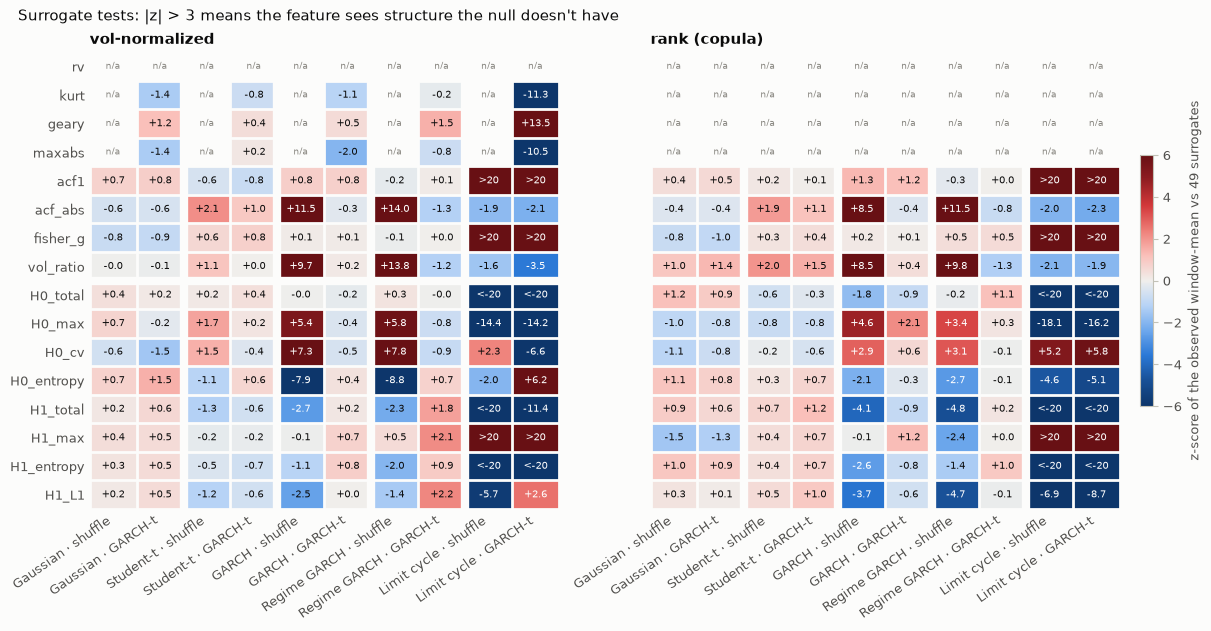

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6.2), sharey=True)
for ax, norm in zip(axes, ("vol", "rank")):
    Z = pd.DataFrame({f"{g} · {k}": zs[norm, g, k] for g in SUR_GENS for k in NULLS}).loc[ROWS]
    im = P.heatmap(ax, Z, P.DIVERGING, -6, 6, fmt="{:+.1f}", fontsize=7.5, clip_text=20)
    ax.axhline(len(F.CLASSICAL) - 0.5, color=P.SURFACE, lw=6)
    for j in range(2, Z.shape[1], 2):
        ax.axvline(j - 0.5, color=P.SURFACE, lw=6)
    ax.set_title(TITLES[norm])
fig.colorbar(im, ax=axes, shrink=0.55, pad=0.02, label="z-score of the observed window-mean vs 49 surrogates")
fig.suptitle("Surrogate tests: |z| > 3 means the feature sees structure the null doesn't have",
             x=0.01, ha="left", fontsize=10.5)
plt.show()

**Reading the surrogate tests.** The observed pattern matches the predicted table cell for cell.

- **Gaussian and Student-t** are consistent with both nulls: every |z| ≤ 2.1. The GARCH-t fitted to the Student-t series has α = 0.03, β = 0 and ν = 3.8, so it simply *is* an i.i.d. t.
- **GARCH rejects the shuffle null**, in `acf_abs` (+11.5) and `vol_ratio` (+9.7), and topologically in `H0_entropy` (−7.9), `H0_cv` (+7.3) and `H0_max` (+5.4). It is consistent with its own fitted GARCH-t (every |z| ≤ 2.0). So the topological features do see temporal structure, and all of it is GARCH structure.
- **Regime GARCH answers the open question.** At 5,000 days no feature separates it from its fitted GARCH-t: the largest |z| is 2.2 under `vol` and 1.3 under `rank`. The fit absorbs the regime shifts as near-unit persistence (α + β = 0.992), the classic spurious-persistence effect (Lamoureux & Lastrapes 1990). In the thread's words, topology here "is just rediscovering GARCH", and so is every other statistic.
- **The limit cycle rejects both nulls in every normalization**, with z-scores beyond ±20.
- **Under `rank`** the pattern is the same with smaller z-scores. The $H_1$ features respond to dependence alone (GARCH vs shuffle: `H1_total` −4.1, `H1_L1` −3.7).

### Does more data separate regime switching from GARCH?

Run the same test for Regime GARCH against its fitted GARCH-t on 40,000 days, about 160 years of daily data, instead of 5,000. Repeat it on four independent series: one z-score of about 3 among 15 features is not evidence, but the same feature at about 3 on every series is.

In [14]:
t0 = time.time()
long_z, long_fits = {}, {}
for i in range(4):
    rng = rng_for(f"surrogates/long/{i}")
    x = simulate("Regime GARCH", 400 * cfg.w, rng)
    W = F.make_windows(x, cfg.w)[0]
    long_fits[f"series {i + 1}"] = SG.fit_garch_t(x)
    sur = np.vstack([F.make_windows(S.standardize(SG.garch_t_surrogate(long_fits[f"series {i + 1}"], len(x), rng)),
                                    cfg.w)[0] for _ in range(B)])
    long_z[f"series {i + 1}"] = surrogate_z(W, sur, "vol")
long_z = pd.DataFrame(long_z).drop(index="rv")
long_z["mean"] = long_z.mean(axis=1)
print(f"{4 * (B + 1) * 400:,} windows in {time.time() - t0:.0f}s")
print("GARCH-t fits:")
display(pd.DataFrame(long_fits).T.round(3))
display(long_z.round(1).rename_axis("z vs GARCH-t, vol-normalized, 40,000 days"))

80,000 windows in 105s
GARCH-t fits:


,omega,alpha,beta,nu
series 1,0.010,0.121,0.870,24.081
series 2,0.010,0.120,0.870,27.219
series 3,0.009,0.117,0.876,19.856
series 4,0.007,0.117,0.879,25.078


,series 1,series 2,series 3,series 4,mean
"z vs GARCH-t, vol-normalized, 40,000 days",,,,,
kurt,-0.7,-0.8,-1.2,0.8,-0.5
geary,1.6,1.9,2.0,0.4,1.5
maxabs,-2.7,-1.9,-2.7,-1.5,-2.2
acf1,-1.1,1.3,1.3,-0.1,0.3
acf_abs,-1.1,-1.5,-1.6,-1.9,-1.5
fisher_g,1.1,0.0,-0.2,-1.1,-0.0
vol_ratio,-1.7,-0.3,-1.9,-1.1,-1.3
H0_total,-2.0,-2.1,-2.5,-2.5,-2.3
H0_max,-1.7,-2.0,-1.6,-1.1,-1.6


**The one place topology leads.** At 40,000 days the normalized $H_1$ summaries are the only features that ever exceed |z| = 3.
- The $H_1$ landscape norm does so on three of the four series (mean z = +3.4), and total $H_1$ persistence on two (mean +2.7).
- No classical statistic reaches 3 on any series. The best is `maxabs` (mean |z| = 2.2), then Geary's ratio (1.5).
- The $H_1$ effects have the same sign on every series.

The likeliest mechanism runs in four steps:
1. The fitted GARCH-t mimics the regime shifts by raising α to about 0.12, against 0.08 within each true regime.
2. Its windows are therefore lumpier at short horizons than the real within-regime dynamics.
3. After vol normalization, lumpier windows mean a denser core and fewer, smaller loops.
4. $H_1$ summaries of the 4-day delay cloud aggregate that joint geometry over all ~40 loops, so they are lower-noise than any one-dimensional statistic. That includes Geary's ratio, which is itself a low-variance robust kurtosis.

Two caveats keep this in proportion:
- **It takes a lot of data.** 40,000 days is about 160 years of one series, and at 5,000 days the same features sit at z ≈ 2.
- **It is a structural test, not a forecast.** It says the regime model isn't GARCH-t, not that anyone could trade on it.

The real-data version is to pool: a cross-section of assets, or intraday bars, can supply the effective sample.

## 7 · The one place topology should win: a cycle vs its Gaussian twin

If returns were a linear Gaussian process, topology could add nothing that the autocovariances don't already give. So the sharpest test of "TDA earns its keep on non-Gaussian structure" is to compare the limit cycle with a twin that has the **same marginal distribution and the same spectrum**, and differs only in its nonlinear temporal structure.

The twin is an **IAAFT surrogate** (Schreiber & Schmitz 1996). It iterates between imposing the cycle's Fourier amplitudes and rank-remapping onto the cycle's values, so the result is a linear Gaussian process seen through a monotone map. What it loses is the limit cycle's *stable amplitude*: its envelope wanders, so the ring fills in.

Sweep the cycle's share of variance from 10% to 80% (200 windows each, `vol` normalization) and ask two questions:
- **(A) Detection:** how well each statistic separates the cycle from i.i.d. noise.
- **(B) Non-Gaussianity:** how well each statistic separates the cycle from its twin. `acf1` and `fisher_g` are functions of the spectrum, so they should sit near zero in panel B by construction.

In [15]:
SHARES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
ROWS_VOL = [f for f in ROWS if f != "rv"]
null_vol = feats["vol", "null"]
t0 = time.time()
vs_null, vs_twin = {}, {}
for share in SHARES:
    rng = rng_for(f"twin/{share}")
    x = S.standardize(S.limit_cycle(200 * cfg.w, 8, rng, noise=0.3, share=share))
    twin = SG.iaaft(x, rng)
    fc = F.compute_features(F.make_windows(x, cfg.w)[0], "vol", cfg)[0]
    ft = F.compute_features(F.make_windows(twin, cfg.w)[0], "vol", cfg)[0]
    vs_null[share] = {f: 2 * E.auc(fc[f], null_vol[f]) - 1 for f in ROWS_VOL}
    vs_twin[share] = {f: 2 * E.auc(fc[f], ft[f]) - 1 for f in ROWS_VOL}
vs_null, vs_twin = pd.DataFrame(vs_null), pd.DataFrame(vs_twin)
print(f"{2 * len(SHARES) * 200:,} windows in {time.time() - t0:.0f}s")
print("D, cycle vs its IAAFT twin (positive: larger for the cycle):")
display(vs_twin.round(2))

3,200 windows in 10s
D, cycle vs its IAAFT twin (positive: larger for the cycle):


,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8
kurt,-0.01,0.01,0.07,0.13,0.13,0.29,0.31,0.34
geary,-0.03,-0.02,-0.04,-0.11,-0.12,-0.24,-0.25,-0.26
maxabs,-0.04,0.01,0.08,0.09,0.07,0.27,0.31,0.36
acf1,0.01,0.06,0.05,0.07,0.12,0.14,0.11,0.13
acf_abs,0.06,-0.09,-0.16,-0.36,-0.53,-0.57,-0.78,-0.91
fisher_g,-0.06,0.15,0.20,0.23,0.26,0.33,0.33,0.29
vol_ratio,0.06,-0.07,-0.13,-0.31,-0.30,-0.31,-0.50,-0.63
H0_total,-0.01,0.01,-0.03,-0.06,-0.15,-0.20,-0.27,-0.26
H0_max,-0.05,-0.02,0.02,-0.04,-0.08,0.09,0.03,-0.05
H0_cv,-0.05,-0.06,0.05,-0.08,-0.00,0.20,0.16,0.14


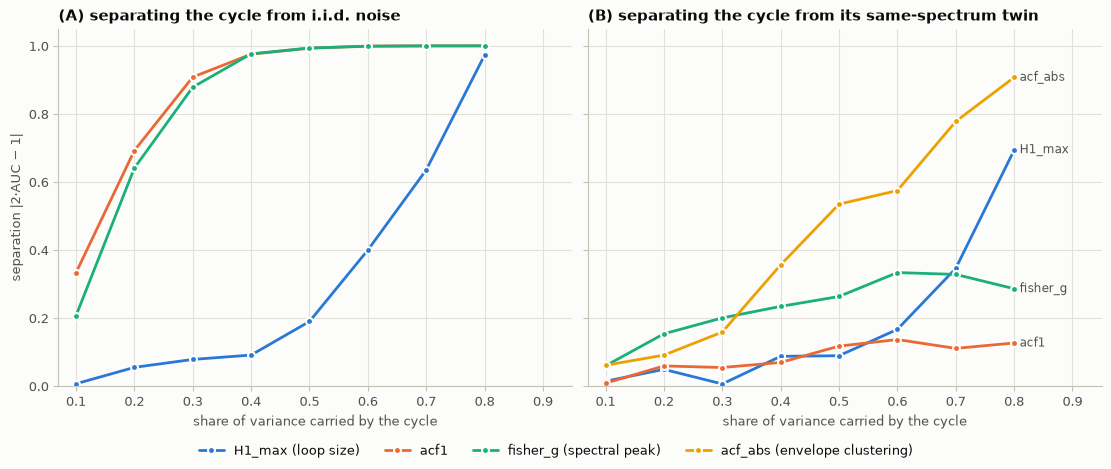

In [16]:
SHOW = ["H1_max", "acf1", "fisher_g", "acf_abs"]
LABEL = {"H1_max": "H1_max (loop size)", "acf1": "acf1", "fisher_g": "fisher_g (spectral peak)",
         "acf_abs": "acf_abs (envelope clustering)"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
panels = [(axes[0], vs_null, SHOW[:3], "(A) separating the cycle from i.i.d. noise"),
          (axes[1], vs_twin, SHOW, "(B) separating the cycle from its same-spectrum twin")]
for ax, tab, feats_shown, title in panels:
    for i, f in enumerate(feats_shown):
        v = tab.loc[f].abs()
        ax.plot(SHARES, v, color=P.SERIES[i], marker="o", ms=5, mec=P.SURFACE, mew=1.5,
                label=LABEL[f] if ax is axes[1] else None)
        if ax is axes[1]:                        # in (A) three lines converge at 1, so the legend carries them
            P.label_end(ax, SHARES[-1], v.iloc[-1], f)
    ax.set(title=title, xlabel="share of variance carried by the cycle", xlim=(0.07, 0.95), ylim=(0, 1.05))
axes[0].set_ylabel("separation |2·AUC − 1|")
fig.legend(loc="outside lower center", ncols=4)
plt.show()

**Reading §7.**

- **(A) Detection.** The spectral statistics find the cycle at a 20–30% share of variance (`acf1`: 0.69 at 20%, 0.91 at 30%). `H1_max` needs 70–80% (0.64 at 70%, 0.97 at 80%). Even in this deliberately favourable geometry, $H_1$ is a far less sensitive periodicity detector than a periodogram.
- **(B) Non-Gaussianity.** `H1_max` does see what distinguishes the limit cycle from its twin (0.69 at 80%), but only when the cycle dominates. The classical envelope statistic `acf_abs` separates them better at every share (0.53 at 50%, 0.91 at 80%).
  - The reason is simple: a stable amplitude is a statement about the envelope $\lvert r_t\rvert$, and the twin's wandering envelope is literally volatility clustering.
  - `acf1` and `fisher_g` stay low (at most 0.14 and 0.33). They are not exactly zero because per-window estimates also feel the local amplitude, even though the global spectra match.

So "TDA earns its keep on non-Gaussian structure" is true but not sufficient. The structure also has to be something no cheap nonlinear statistic already targets.

## 8 · Regime switches with known dates

The thread's change-point argument: a window that spans calm and turbulent days is a scale mixture, a dense core plus a sparse halo, so the spread of $H_0$ deaths should flag it.

Test it on a 50,000-day Regime GARCH path with windows every 5 days. Label each window:
- **straddle**: it contains exactly one switch, with at least 20% of its days on each side;
- **pure**: it contains no switch;
- the rest are left out.

Overlapping windows are strongly dependent, so the classifiers use **blocked** cross-validation on 10 contiguous stretches of time.

In [17]:
rng = rng_for("regimes")
T_REG, STEP_REG = 50_000, 5
r, states = S.regime_garch(T_REG, rng=rng, **GEN["Regime GARCH"])
x = S.standardize(r)
switches = S.switch_dates(states)
W, ends = F.make_windows(x, cfg.w, step=STEP_REG)

t0 = time.time()
fr = {norm: F.compute_features(W, norm, cfg)[0] for norm in ("vol", "rank")}
for frame in fr.values():
    frame["log_sigma"] = np.log(W.std(axis=1))       # vol enters as its own feature
lab = E.switch_labels(ends, cfg.w, switches)
print(f"{2 * len(W):,} windows in {time.time() - t0:.0f}s; {len(switches)} switches; "
      f"{(lab == 1).sum():,} straddle windows, {(lab == 0).sum():,} pure, {(lab == -1).sum():,} left out")

CLASSICAL_R = ["log_sigma", *[f for f in F.CLASSICAL if f != "rv"]]
CAND = CLASSICAL_R + list(F.TDA_SCALARS)
uni = pd.DataFrame({norm: {f: 2 * E.auc(fr[norm].loc[lab == 1, f], fr[norm].loc[lab == 0, f]) - 1
                           for f in CAND} for norm in ("vol", "rank")})
uni.loc[["kurt", "geary", "maxabs"], "rank"] = np.nan              # constant under ranks
display(uni.reindex(uni["vol"].abs().sort_values(ascending=False).index).round(2)
        .rename_axis("D, straddle vs pure"))

m = lab >= 0
groups = ends[m] * 10 // T_REG                                     # 10 contiguous stretches of time
SETS = {"classical": CLASSICAL_R,
        "log σ + TDA summaries": ["log_sigma", *F.TDA_SCALARS],
        "classical + TDA summaries": CLASSICAL_R + list(F.TDA_SCALARS)}
display(pd.Series({k: E.cv_auc(fr["vol"].loc[m, v].to_numpy(), lab[m], groups=groups) for k, v in SETS.items()},
                  name="blocked-CV AUC, straddle vs pure").round(3).to_frame())

19,962 windows in 26s; 198 switches; 1,423 straddle windows, 6,913 pure, 1,645 left out


,vol,rank
"D, straddle vs pure",,
H0_entropy,-0.86,-0.42
H0_cv,0.84,0.45
geary,-0.83,NaN
acf_abs,0.80,0.76
kurt,0.79,NaN
vol_ratio,0.74,0.67
H1_total,-0.71,-0.53
H1_L1,-0.64,-0.50
log_sigma,0.64,0.64


,"blocked-CV AUC, straddle vs pure"
classical,0.965
log σ + TDA summaries,0.962
classical + TDA summaries,0.966


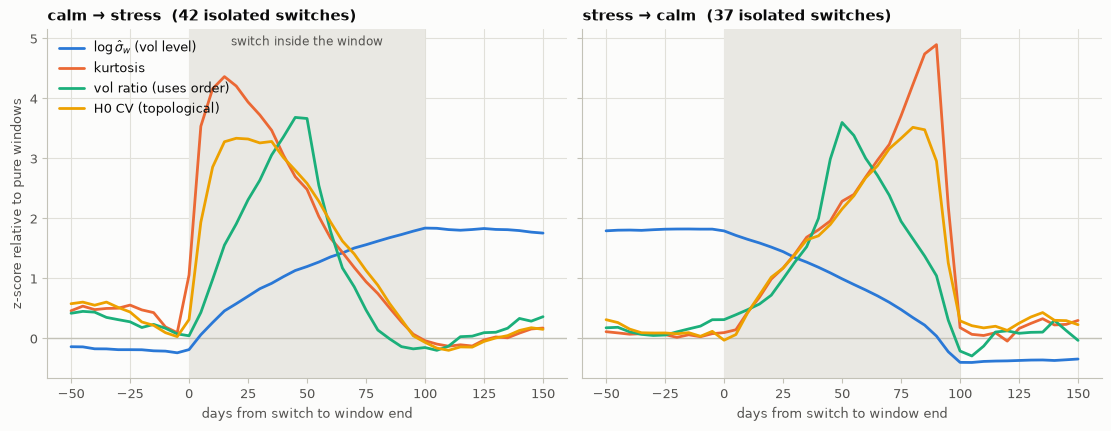

In [18]:
isolated = [t for i, t in enumerate(switches)
            if (i == 0 or t - switches[i - 1] > cfg.w) and (i == len(switches) - 1 or switches[i + 1] - t > cfg.w)]
LAGS = np.arange(-50, 151, 5)
EV = ["log_sigma", "kurt", "vol_ratio", "H0_cv"]
EV_LABEL = {"log_sigma": r"$\log\hat\sigma_w$ (vol level)", "kurt": "kurtosis", "vol_ratio": "vol ratio (uses order)",
            "H0_cv": "H0 CV (topological)"}
pure = fr["vol"].loc[lab == 0, EV]
zfeat = (fr["vol"][EV] - pure.mean()) / pure.std()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, into, title in [(axes[0], 1, "calm → stress"), (axes[1], 0, "stress → calm")]:
    evs = [t for t in isolated if states[t] == into]
    avg = E.event_average(zfeat, ends, evs, LAGS)
    ax.axvspan(0, cfg.w, color=P.SHADE, lw=0)
    ax.axhline(0, color=P.BASELINE, lw=1)
    for i, f in enumerate(EV):
        ax.plot(avg.index, avg[f], color=P.SERIES[i], label=EV_LABEL[f])
    ax.set(title=f"{title}  ({len(evs)} isolated switches)", xlabel="days from switch to window end")
axes[0].set_ylabel("z-score relative to pure windows")
axes[0].legend(loc="upper left")
axes[0].annotate("switch inside the window", (cfg.w / 2, axes[0].get_ylim()[1]), xytext=(0, -12),
                 textcoords="offset points", ha="center", fontsize=8.5, color=P.INK_2)
plt.show()

**Reading §8.**

- **The two-scale claim holds.** The best single detectors of a straddling window are `H0_entropy` (D = −0.86) and `H0_cv` (+0.84), just ahead of Geary's ratio (−0.83), `acf_abs` (+0.80) and kurtosis (+0.79). That is a statistical tie with the robust-kurtosis statistics, which is what a scale mixture predicts: `H0_cv` works as a topological kurtosis. Under `rank` they weaken to about 0.4, because the rank transform removes most of the scale mixing that drives them.
- **Timing is where they are interesting.**
  - After calm → stress, kurtosis and `H0_cv` fire almost at once, reaching z ≈ 2–3.5 within 5–10 days, while only a few stress days sit at the end of the window.
  - The order-aware `vol_ratio` peaks only once the switch is mid-window, about 45 days in. The vol level lags throughout.
  - For stress → calm the shape statistics peak late instead (80–90 days), when a few stress days are left at the start of an otherwise calm window. Mixture statistics are largest at a small mixing fraction.
- **Multivariate, TDA adds nothing.** The blocked-CV AUC is 0.965 for the classical block, 0.962 for log σ plus the TDA summaries, and 0.966 for both together.

**Where a dissertation-style detector plugs in.** A Rips diagram of a delay cloud is order-free, so it cannot tell calm-then-stress from stress-then-calm. A change-point detector has to compare clouds *across* time: a distance between the diagrams of adjacent windows, or a method that flags where local topological features change. Any detector that maps the stream of windows to one score per window end can be evaluated on this path, with its known switch dates, using exactly the tools here:
- `E.switch_labels` with `E.auc` or `E.cv_auc` for detection;
- `E.event_average` for timing.

The table and figure above set the bar to beat.

## 9 · What this means for the real-data study

| mechanism | topological features that respond (vol-normalized) | best classical statistic | TDA adds beyond classical? | separable from a fitted GARCH-t? |
|---|---|---|---|---|
| fat tails (i.i.d.) | `H0_cv` ↑, `H0_entropy` ↓, `H0_max` ↑, $H_1$ ↓ | `kurt`, `geary` | no | no, and rightly so: the fit is an i.i.d. t |
| volatility clustering | the same two-scale signature, weaker; `H0_max` sees runs of large moves | `acf_abs` | no | no: it *is* GARCH |
| regime switches | `H0_entropy` and `H0_cv`, the best and fastest single switch detectors | `geary`, `acf_abs`, `kurt` | no | not at 5,000 days; at 40,000 days only $H_1$ starts to (z ≈ 3) |
| genuine cycle | `H1_max` ↑, plus most $H_0$ features | `acf1` and `fisher_g`, which detect it at 20–30% of variance | $H_1$ sees the stable amplitude, but `acf_abs` sees it better | yes, massively |

**Design decisions this settles for notebook 02:**

1. **Never read unnormalized landscape norms as shape.** Work with `vol` (or `rank`) windows, and put $\log\hat\sigma_w$ in every model as its own regressor.
   - Run the Gidea–Katz replication both ways. How much of the crash run-up survives normalization is the central hypothesis.
   - On GARCH windows, two-thirds of the raw statistic's variance is scale.
2. **Expect $H_0$, not $H_1$, to carry whatever shape signal daily returns have.** Tails and mixing live in $H_0$, and stable cycles in daily returns are implausible.
3. **Keep two bars to clear.** Structure has to beat GARCH-t surrogates, and forecasts have to beat a GARCH baseline, not just HAR. Use Clark–West for the nested comparison, log every configuration (`results/runs.jsonl`), and hold out the final stretch of data.
4. **Pool, and compare with flexible learners.** The only topological edge found here is statistical efficiency in joint short-horizon geometry, and it needs a large effective sample. That points to a cross-section of assets or to intraday data rather than a single index.
5. **Build the change-point angle across windows, not within one.** That is where an order-aware topological detector could be genuinely new.

In [19]:
def as_json(df):
    df = df.copy()
    df.columns = [" | ".join(map(str, c)) if isinstance(c, tuple) else str(c) for c in df.columns]
    return df.round(3).astype(object).where(df.notna(), None).to_dict()


E.log_run(ROOT / "results" / "runs.jsonl", "01_synthetic_mechanisms",
          config={"w": cfg.w, "m": cfg.m, "tau": cfg.tau, "seed": MASTER_SEED, "generators": GEN,
                  "n_windows": N_WIN, "n_null": N_NULL, "surrogates": B, "trap_days": T_TRAP,
                  "regime_days": T_REG},
          metrics={"response_vol": as_json(resp["vol"]), "response_rank": as_json(resp["rank"]),
                   "block_auc": as_json(auc_tab), "forecast": as_json(pd.DataFrame(fc_tab).T),
                   "twin_vs_cycle": as_json(vs_twin), "switch_univariate": as_json(uni),
                   "regime_vs_garch_t_40k_days": as_json(long_z)})
print("appended this run to results/runs.jsonl")

appended this run to results/runs.jsonl
